In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random


In [3]:
transformer_model = nn.Transformer(nhead=16, num_encoder_layers=12)
src = torch.rand((10, 32, 512))
tgt = torch.rand((20, 32, 512))
out = transformer_model(src, tgt)


C:\Users\whitedk\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [4]:
class Transformer(nn.Module):
    def __init__(self, num_tokens, dim_model, num_heads, num_encoder_layers, num_decoder_layers, dropout_p, ):
        super().__init__()
 
        # Layers
        self.transformer = nn.Transformer(
            d_model=dim_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout_p,
        )
 
    def forward(self):
        pass

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, dim_model, dropout_p, max_len):
        super().__init__()
        
        self.dropout = nn.Dropout(dropout_p)
 
        # Encoding - From formula
        pos_encoding = torch.zeros(max_len, dim_model)
        positions_list = torch.arange(0, max_len, dtype=torch.float).view(-1, 1) # 0, 1, 2, 3, 4, 5
        division_term = torch.exp(torch.arange(0, dim_model, 2).float() * (-math.log(10000.0)) / dim_model) # 1000^(2i/dim_model)
 
        pos_encoding[:, 0::2] = torch.sin(positions_list * division_term)
        pos_encoding[:, 1::2] = torch.cos(positions_list * division_term)
 
        # Saving buffer (same as parameter without gradients needed)
        pos_encoding = pos_encoding.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pos_encoding", pos_encoding)
 
    def forward(self, token_embedding: torch.tensor) -> torch.tensor:
        # Residual connection + pos encoding
        return self.dropout(token_embedding + self.pos_encoding[:token_embedding.size(0), :])

In [6]:
class Transformer(nn.Module):
    # Constructor
    def __init__(self, num_tokens, dim_model, num_heads, num_encoder_layers, num_decoder_layers, dropout_p,):
        super().__init__()
 
        # INFO
        self.model_type = "Transformer"
        self.dim_model = dim_model
 
        # LAYERS
        self.positional_encoder = PositionalEncoding(dim_model=dim_model, dropout_p=dropout_p, max_len=5000)
        self.embedding = nn.Embedding(num_tokens, dim_model)
        self.transformer = nn.Transformer(
            d_model=dim_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout_p,
        )
        self.out = nn.Linear(dim_model, num_tokens)
 
    def forward(self, src, tgt, tgt_mask=None, src_pad_mask=None, tgt_pad_mask=None):
        # src, Tgt size -> (batch_size, src sequence length)
 
        # Embedding + positional encoding - Out size = (batch_size, sequence length, dim_model)
        src = self.embedding(src) * math.sqrt(self.dim_model)
        tgt = self.embedding(tgt) * math.sqrt(self.dim_model)
        src = self.positional_encoder(src)
        tgt = self.positional_encoder(tgt)
 
        src = src.permute(1,0,2)
        tgt = tgt.permute(1,0,2)
 
        # Transformer blocks - Out size = (sequence length, batch_size, num_tokens)
        transformer_out = self.transformer(src, tgt, tgt_mask=tgt_mask, src_key_padding_mask=src_pad_mask, tgt_key_padding_mask=tgt_pad_mask)
        out = self.out(transformer_out)
 
        return out
 
    def get_tgt_mask(self, size) -> torch.tensor:
        mask = torch.tril(torch.ones(size, size) == 1) # Lower triangular matrix
        mask = mask.float()
        mask = mask.masked_fill(mask == 0, float('-inf')) # Convert zeros to -inf
        mask = mask.masked_fill(mask == 1, float(0.0)) # Convert ones to 0
 
        return mask
 
    def create_pad_mask(self, matrix: torch.tensor, pad_token: int) -> torch.tensor:
        return (matrix == pad_token)

In [7]:
def generate_random_data(n):
    SOS_token = np.array([2])
    EOS_token = np.array([3])
    length = 8
 
    data = []
 
    # 1,1,1,1,1 -> 1,1,1,1,1
    for i in range(n // 3):
        X = np.concatenate((SOS_token, np.ones(length), EOS_token))
        y = np.concatenate((SOS_token, np.ones(length), EOS_token))
        data.append([X, y])
 
    # 0,0,0,0 -> 0,0,0,0
    for i in range(n // 3):
        X = np.concatenate((SOS_token, np.zeros(length), EOS_token))
        y = np.concatenate((SOS_token, np.zeros(length), EOS_token))
        data.append([X, y])
 
    # 1,0,1,0 -> 1,0,1,0,1
    for i in range(n // 3):
        X = np.zeros(length)
        start = random.randint(0, 1)
 
        X[start::2] = 1
 
        y = np.zeros(length)
        if X[-1] == 0:
            y[::2] = 1
        else:
            y[1::2] = 1
 
        X = np.concatenate((SOS_token, X, EOS_token))
        y = np.concatenate((SOS_token, y, EOS_token))
        data.append([X, y])
 
    np.random.shuffle(data)
 
    return data
 
#크기가 16인 배치 형태로 만들어 줍니다.
def batchify_data(data, batch_size=16, padding=False, padding_token=-1):
    batches = []
    for idx in range(0, len(data), batch_size):
        # batch_size 크기가 아닌 경우 마지막 비트를 얻지 않도록 합니다.
        if idx + batch_size < len(data):
            # 여기서 배치의 최대 길이를 가져와 PAD 토큰으로 길이를 정규화해야 합니다.
            if padding:
                max_batch_length = 0
                # batch에서 가장 긴 문장 가져오기
                for seq in data[idx : idx + batch_size]:
                    if len(seq) > max_batch_length:
                        max_batch_length = len(seq)
 
                # 최대 길이에 도달할 때까지 X 패딩 토큰을 추가합니다.
                for seq_idx in range(batch_size):
                    remaining_length = max_bath_length - len(data[idx + seq_idx])
                    data[idx + seq_idx] += [padding_token] * remaining_length
 
            batches.append(np.array(data[idx : idx + batch_size]).astype(np.int64))
 
    print(f"{len(batches)} batches of size {batch_size}")
 
    return batches
 
 
train_data = generate_random_data(9000)
val_data = generate_random_data(3000)
 
train_dataloader = batchify_data(train_data)
val_dataloader = batchify_data(val_data)

562 batches of size 16
187 batches of size 16


In [10]:
generate_random_data(10)

[[array([2., 1., 0., 1., 0., 1., 0., 1., 0., 3.]),
  array([2., 1., 0., 1., 0., 1., 0., 1., 0., 3.])],
 [array([2., 1., 1., 1., 1., 1., 1., 1., 1., 3.]),
  array([2., 1., 1., 1., 1., 1., 1., 1., 1., 3.])],
 [array([2., 1., 0., 1., 0., 1., 0., 1., 0., 3.]),
  array([2., 1., 0., 1., 0., 1., 0., 1., 0., 3.])],
 [array([2., 1., 1., 1., 1., 1., 1., 1., 1., 3.]),
  array([2., 1., 1., 1., 1., 1., 1., 1., 1., 3.])],
 [array([2., 0., 0., 0., 0., 0., 0., 0., 0., 3.]),
  array([2., 0., 0., 0., 0., 0., 0., 0., 0., 3.])],
 [array([2., 0., 1., 0., 1., 0., 1., 0., 1., 3.]),
  array([2., 0., 1., 0., 1., 0., 1., 0., 1., 3.])],
 [array([2., 0., 0., 0., 0., 0., 0., 0., 0., 3.]),
  array([2., 0., 0., 0., 0., 0., 0., 0., 0., 3.])],
 [array([2., 0., 0., 0., 0., 0., 0., 0., 0., 3.]),
  array([2., 0., 0., 0., 0., 0., 0., 0., 0., 3.])],
 [array([2., 1., 1., 1., 1., 1., 1., 1., 1., 3.]),
  array([2., 1., 1., 1., 1., 1., 1., 1., 1., 3.])]]

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Transformer(num_tokens=4,
                    dim_model=8,
                    num_heads=2,
                    num_encoder_layers=3,
                    num_decoder_layers=3,
                    dropout_p=0.1).to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

In [12]:
def train_loop(model, opt, loss_fn, dataloader):
    model.train()
    total_loss = 0
 
    for batch in dataloader:
        X, y = batch[:, 0], batch[:, 1]
        X, y = torch.tensor(X).to(device), torch.tensor(y).to(device)
 
        # 이제 tgt를 1만큼 이동하여 <SOS>를 사용하여 pos 1에서 토큰을 예측
        y_input = y[:,:-1]
        y_expected = y[:,1:]
 
        # 다음 단어를 마스킹하려면 마스크 가져오기
        sequence_length = y_input.size(1)
        tgt_mask = model.get_tgt_mask(sequence_length).to(device)
 
        # X, y_input 및 tgt_mask를 전달하여 표준 training
        pred = model(X, y_input, tgt_mask)
 
        # Permute 를 수행하여 batch first
        pred = pred.permute(1, 2, 0)      
        loss = loss_fn(pred, y_expected)
 
        opt.zero_grad()
        loss.backward()
        opt.step()
 
        total_loss += loss.detach().item()
 
    return total_loss / len(dataloader)

In [13]:
def validation_loop(model, loss_fn, dataloader):
    model.eval()
    total_loss = 0
 
    with torch.no_grad():
        for batch in dataloader:
            X, y = batch[:, 0], batch[:, 1]
            X, y = torch.tensor(X, dtype=torch.long, device=device), torch.tensor(y, dtype=torch.long, device=device)
 
            y_input = y[:,:-1]
            y_expected = y[:,1:]
 
            sequence_length = y_input.size(1)
            tgt_mask = model.get_tgt_mask(sequence_length).to(device)
 
            pred = model(X, y_input, tgt_mask)
 
            pred = pred.permute(1, 2, 0)      
            loss = loss_fn(pred, y_expected)
            total_loss += loss.detach().item()
 
    return total_loss / len(dataloader)

In [14]:
def fit(model, opt, loss_fn, train_dataloader, val_dataloader, epochs):  
    # plotting하기 위한 리스트 생성 
    train_loss_list, validation_loss_list = [], []
 
    print("Training and validating model")
    for epoch in range(epochs):
        print("-"*25, f"Epoch {epoch + 1}","-"*25)
 
        train_loss = train_loop(model, opt, loss_fn, train_dataloader)
        train_loss_list += [train_loss]
 
        validation_loss = validation_loop(model, loss_fn, val_dataloader)
        validation_loss_list += [validation_loss]
 
        print(f"Training loss: {train_loss:.4f}")
        print(f"Validation loss: {validation_loss:.4f}")
        print()
 
    return train_loss_list, validation_loss_list

In [15]:
train_loss_list, validation_loss_list = fit(model, opt, loss_fn, train_dataloader, val_dataloader, 10)

Training and validating model
------------------------- Epoch 1 -------------------------
Training loss: 0.6163
Validation loss: 0.4211

------------------------- Epoch 2 -------------------------
Training loss: 0.4218
Validation loss: 0.3784

------------------------- Epoch 3 -------------------------
Training loss: 0.3856
Validation loss: 0.3293

------------------------- Epoch 4 -------------------------
Training loss: 0.3528
Validation loss: 0.2902

------------------------- Epoch 5 -------------------------
Training loss: 0.3236
Validation loss: 0.2526

------------------------- Epoch 6 -------------------------
Training loss: 0.2972
Validation loss: 0.2292

------------------------- Epoch 7 -------------------------
Training loss: 0.2748
Validation loss: 0.1927

------------------------- Epoch 8 -------------------------
Training loss: 0.2566
Validation loss: 0.1743

------------------------- Epoch 9 -------------------------
Training loss: 0.2460
Validation loss: 0.1687

-------

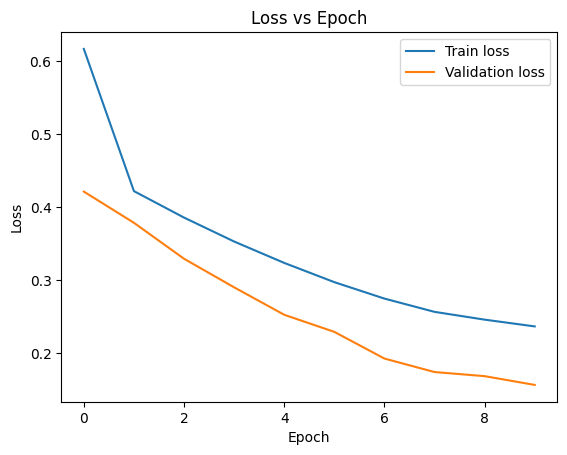

In [23]:
import matplotlib.pyplot as plt

plt.plot(train_loss_list, label = "Train loss")
plt.plot(validation_loss_list, label = "Validation loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [59]:
def predict(model, input_sequence, max_length=15, SOS_token=2, EOS_token=3):
    model.eval()
 
    y_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)
 
    num_tokens = len(input_sequence[0])
 
    for _ in range(max_length):
        # Get source mask
        tgt_mask = model.get_tgt_mask(y_input.size(1)).to(device)
 
        pred = model(input_sequence, y_input, tgt_mask)
 
        next_item = pred.topk(1)[1].view(-1)[-1].item() # num with highest probability
        next_item = torch.tensor([[next_item]], device=device)
 
        # Concatenate previous input with predicted best word
        y_input = torch.cat((y_input, next_item), dim=1)
 
        # Stop if model predicts end of sentence
        if next_item.view(-1).item() == EOS_token:
            break
 
    return y_input.view(-1).tolist()
 
 
# Here we test some examples to observe how the model predicts
examples = [
    torch.tensor([[0, 0, 0, 0, 0, 0, 0]], dtype=torch.long, device=device),
    torch.tensor([[1, 1, 1, 1, 1, 1, 1]], dtype=torch.long, device=device),
    torch.tensor([[1, 0, 1, 0, 1, 0, 1]], dtype=torch.long, device=device),
    torch.tensor([[0, 1, 0, 1, 0, 1, 0]], dtype=torch.long, device=device),
    torch.tensor([[0, 1, 0, 1, 0, 1, 0]], dtype=torch.long, device=device),
    torch.tensor([[0, 1]], dtype=torch.long, device=device)
]
 
for idx, example in enumerate(examples):
    result = predict(model, example)
    print(f"Example {idx}")
    print(f"Input: {example.view(-1).tolist()[:]}")
    print(f"Continuation: {result[1:-1]}")
    print()

Example 0
Input: [0, 0, 0, 0, 0, 0, 0]
Continuation: [0, 0, 0, 0, 0, 0, 0, 0, 0]

Example 1
Input: [1, 1, 1, 1, 1, 1, 1]
Continuation: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Example 2
Input: [1, 0, 1, 0, 1, 0, 1]
Continuation: [1, 1, 1, 0, 1, 0, 1, 0, 1]

Example 3
Input: [0, 1, 0, 1, 0, 1, 0]
Continuation: [1, 0, 1, 0, 1, 0, 1, 0, 1]

Example 4
Input: [0, 1, 0, 1, 0, 1, 0]
Continuation: [1, 0, 1, 0, 1, 0, 1, 0, 1]

Example 5
Input: [0, 1]
Continuation: [1, 0, 1, 0, 1, 0, 1, 0, 1]



In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SOS_token = 2
EOS_token = 3
PAD_token = 0
VOCAB_SIZE = 4  # 0, 1, 2(SOS), 3(EOS)
MAX_LEN = 10

def generate_random_data(n):
    SOS = np.array([SOS_token])
    EOS = np.array([EOS_token])
    length = 8
    data = []

    num_each = n // 5

    # 1. all 1
    for _ in range(num_each):
        x = np.ones(length)
        y = np.ones(length)
        data.append([
            np.concatenate((SOS, x, EOS)),
            np.concatenate((SOS, y, EOS))
        ])

    # 2. all 0
    for _ in range(num_each):
        x = np.zeros(length)
        y = np.zeros(length)
        data.append([
            np.concatenate((SOS, x, EOS)),
            np.concatenate((SOS, y, EOS))
        ])

    # 3. alternating 1/0
    for _ in range(num_each):
        x = np.zeros(length)
        start = random.randint(0, 1)
        x[start::2] = 1
        y = np.zeros(length)
        if x[-1] == 0:
            y[::2] = 1
        else:
            y[1::2] = 1
        data.append([
            np.concatenate((SOS, x, EOS)),
            np.concatenate((SOS, y, EOS))
        ])

    # 4. 랜덤 시퀀스 (비정형)
    for _ in range(num_each):
        x = np.random.randint(0, 2, length)
        y = np.roll(x, 1)  # 오른쪽으로 한 칸 shift 예시
        data.append([
            np.concatenate((SOS, x, EOS)),
            np.concatenate((SOS, y, EOS))
        ])

    # 5. 경계 테스트용: 중간만 1, 앞뒤는 0
    for _ in range(num_each):
        x = np.zeros(length)
        x[length // 2 - 1 : length // 2 + 1] = 1
        y = np.flip(x)
        data.append([
            np.concatenate((SOS, x, EOS)),
            np.concatenate((SOS, y, EOS))
        ])

    np.random.shuffle(data)
    return data

def batchify_data(data, batch_size=16):
    batches = []
    for idx in range(0, len(data), batch_size):
        if idx + batch_size <= len(data):
            batch = data[idx:idx+batch_size]
            X = [d[0] for d in batch]
            Y = [d[1] for d in batch]
            X = torch.tensor(X, dtype=torch.long)
            Y = torch.tensor(Y, dtype=torch.long)
            batches.append((X.to(device), Y.to(device)))
    return batches

### 2. Transformer 모델 정의 ###
class Seq2SeqTransformer(nn.Module):
    def __init__(self, num_tokens, dim_model=128, num_heads=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(num_tokens, dim_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, MAX_LEN+2, dim_model))
        self.transformer = nn.Transformer(
            d_model=dim_model,
            nhead=num_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )
        self.fc_out = nn.Linear(dim_model, num_tokens)

    def get_tgt_mask(self, size):
        return torch.triu(torch.ones(size, size, device=device) * float('-inf'), diagonal=1)

    def forward(self, src, tgt, tgt_mask):
        src_emb = self.embedding(src) + self.pos_encoder[:, :src.size(1)]
        tgt_emb = self.embedding(tgt) + self.pos_encoder[:, :tgt.size(1)]
        output = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask)
        return self.fc_out(output)

### 3. 학습 루프 ###
def train_loop(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in dataloader:
        y_input = y[:, :-1]
        y_expected = y[:, 1:]
        tgt_mask = model.get_tgt_mask(y_input.size(1))

        pred = model(x, y_input, tgt_mask)
        pred = pred.permute(0, 2, 1)  # (batch, vocab, seq)

        loss = criterion(pred, y_expected)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

### 4. 예측 함수 ###
def predict(model, input_seq, max_len=15):
    model.eval()
    y_input = torch.tensor([[SOS_token]], device=device)
    input_seq = input_seq.unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_len):
            tgt_mask = model.get_tgt_mask(y_input.size(1))
            out = model(input_seq, y_input, tgt_mask)
            next_token = out[0, -1].argmax(dim=-1).item()
            y_input = torch.cat([y_input, torch.tensor([[next_token]], device=device)], dim=1)
            if next_token == EOS_token:
                break
    return y_input.view(-1).tolist()

### 5. 실행 ###
# 학습 준비
train_data = generate_random_data(3000)
val_data = generate_random_data(500)
train_batches = batchify_data(train_data, batch_size=32)
val_batches = batchify_data(val_data, batch_size=32)

model = Seq2SeqTransformer(num_tokens=VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 학습
for epoch in range(20):
    loss = train_loop(model, train_batches, optimizer, criterion)
    print(f"[Epoch {epoch+1}] Loss: {loss:.4f}")

# 예측 테스트
print("\n--- Sample Predictions ---")
for i in range(5):
    input_seq = torch.tensor(val_data[i][0], dtype=torch.long)
    target_seq = val_data[i][1][1:-1].tolist()  # SOS/EOS 제외
    pred_seq = predict(model, input_seq)[1:]     # SOS 제거
    if EOS_token in pred_seq:
        pred_seq = pred_seq[:pred_seq.index(EOS_token)]
    print(f"[{i}] Input  : {input_seq.tolist()[1:-1]}")
    print(f"     Target : {target_seq}")
    print(f"     Output : {pred_seq}\n")


[Epoch 1] Loss: 0.2861
[Epoch 2] Loss: 0.1159
[Epoch 3] Loss: 0.0574
[Epoch 4] Loss: 0.0230
[Epoch 5] Loss: 0.0195
[Epoch 6] Loss: 0.0137
[Epoch 7] Loss: 0.0241
[Epoch 8] Loss: 0.0178
[Epoch 9] Loss: 0.0208
[Epoch 10] Loss: 0.0132
[Epoch 11] Loss: 0.0146
[Epoch 12] Loss: 0.0064
[Epoch 13] Loss: 0.0080
[Epoch 14] Loss: 0.0375
[Epoch 15] Loss: 0.0152
[Epoch 16] Loss: 0.0064
[Epoch 17] Loss: 0.0136
[Epoch 18] Loss: 0.0148
[Epoch 19] Loss: 0.0054
[Epoch 20] Loss: 0.0088

--- Sample Predictions ---
[0] Input  : [0, 0, 0, 1, 1, 0, 0, 0]
     Target : [0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0]
     Output : [0, 0, 0, 1, 1, 0, 0, 0]

[1] Input  : [0, 1, 0, 1, 0, 1, 0, 1]
     Target : [0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0]
     Output : [0, 1, 0, 1, 0, 1, 0, 1]

[2] Input  : [1, 1, 1, 1, 1, 1, 1, 1]
     Target : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
     Output : [1, 1, 1, 1, 1, 1, 1, 1]

[3] Input  : [0, 0, 0, 0, 0, 0, 0, 0]
     Target : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
     Outp

In [75]:
test_examples = [
    [1, 1, 1, 1, 1, 1, 1, 1],  # all 1
    [0, 1, 0, 1, 0, 1, 0, 1],  # alternating
    [1, 0, 1, 0, 1, 0, 1, 0],  # alternating reversed
    [0, 0, 0, 1, 0, 0, 0, 1],  # 0 0 1
    [0, 1, 0, 0, 1, 0, 0, 0]
]

print("\n--- Balanced Test ---")
for i, inp in enumerate(test_examples):
    inp_tensor = torch.tensor([SOS_token] + inp + [EOS_token], dtype=torch.long)
    pred_seq = predict(model, inp_tensor)[1:]
    if EOS_token in pred_seq:
        pred_seq = pred_seq[:pred_seq.index(EOS_token)]
    print(f"[{i}] Input  : {inp}")
    print(f"     Output : {pred_seq}")


--- Balanced Test ---
[0] Input  : [1, 1, 1, 1, 1, 1, 1, 1]
     Output : [1, 1, 1, 1, 1, 1, 1, 1]
[1] Input  : [0, 1, 0, 1, 0, 1, 0, 1]
     Output : [0, 1, 0, 1, 0, 1, 0, 1]
[2] Input  : [1, 0, 1, 0, 1, 0, 1, 0]
     Output : [1, 0, 1, 0, 1, 0, 1, 0]
[3] Input  : [0, 0, 0, 1, 0, 0, 0, 1]
     Output : [1, 0, 0, 0, 1, 0, 0, 0]
[4] Input  : [0, 1, 0, 0, 1, 0, 0, 0]
     Output : [0, 0, 1, 0, 0, 1, 0, 0]


In [72]:
def evaluate_accuracy(model, data, n=20):
    correct = 0
    total = 0
    for i, (x_arr, y_arr) in enumerate(data[:n]):
        x = torch.tensor(x_arr, dtype=torch.long)
        target = y_arr[1:-1].tolist()  # SOS/EOS 제외

        pred = predict(model, x)[1:]  # SOS 제외
        if EOS_token in pred:
            pred = pred[:pred.index(EOS_token)]

        is_correct = pred == target
        correct += int(is_correct)
        total += 1

        print(f"[{i}] Input     : {x[1:-1].tolist()}")
        print(f"     Target    : {target}")
        print(f"     Predicted : {pred}")
        print(f"     Match     : {is_correct}\n")

    acc = correct / total * 100
    print(f"Accuracy: {correct} / {total} ({acc:.2f}%)")
    return acc

In [78]:
# 예: 개선된 데이터셋 기반 정확도 평가
def build_manual_val_data():
    SOS = [SOS_token]
    EOS = [EOS_token]

    val_data = []

    examples = [
        [1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0, 1],
        [0, 1, 0, 0, 1, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0],
        np.random.randint(0, 2, 8).tolist()
    ]

    for x in examples:
        # 정답을 단순화해서 x 그대로 복사 (또는 패턴 적용 가능)
        y = x.copy()  
        x_tensor = np.array(SOS + x + EOS)
        y_tensor = np.array(SOS + y + EOS)
        val_data.append((x_tensor, y_tensor))

    return val_data

val_data = build_manual_val_data()

evaluate_accuracy(model, val_data, n=20)

[0] Input     : [1, 1, 1, 1, 1, 1, 1, 1]
     Target    : [1, 1, 1, 1, 1, 1, 1, 1]
     Predicted : [1, 1, 1, 1, 1, 1, 1, 1]
     Match     : True

[1] Input     : [0, 0, 0, 0, 0, 0, 0, 0]
     Target    : [0, 0, 0, 0, 0, 0, 0, 0]
     Predicted : [0, 0, 0, 0, 0, 0, 0, 0]
     Match     : True

[2] Input     : [0, 1, 0, 1, 0, 1, 0, 1]
     Target    : [0, 1, 0, 1, 0, 1, 0, 1]
     Predicted : [0, 1, 0, 1, 0, 1, 0, 1]
     Match     : True

[3] Input     : [1, 0, 1, 0, 1, 0, 1, 0]
     Target    : [1, 0, 1, 0, 1, 0, 1, 0]
     Predicted : [1, 0, 1, 0, 1, 0, 1, 0]
     Match     : True

[4] Input     : [0, 0, 0, 1, 0, 0, 0, 1]
     Target    : [0, 0, 0, 1, 0, 0, 0, 1]
     Predicted : [1, 0, 0, 0, 1, 0, 0, 0]
     Match     : False

[5] Input     : [0, 1, 0, 0, 1, 0, 0, 0]
     Target    : [0, 1, 0, 0, 1, 0, 0, 0]
     Predicted : [0, 0, 1, 0, 0, 1, 0, 0]
     Match     : False

[6] Input     : [0, 0, 1, 1, 1, 1, 0, 0]
     Target    : [0, 0, 1, 1, 1, 1, 0, 0]
     Predicted : [0, 0, 0, 

50.0